# Ensemble Methods

---

## Intuition

A single decision tree has high variance: small changes in training data produce very different trees.
Ensemble methods combine many trees so individual errors cancel out.

Two main strategies:

**1. Bagging (Bootstrap Aggregating)**
Train $T$ trees on independent **bootstrap samples** of the data (sample $n$ points with replacement).
Aggregate predictions by majority vote (classification) or mean (regression):
$$\hat{y} = \text{mode}\{h_1(\mathbf{x}),\, h_2(\mathbf{x}),\, \dots,\, h_T(\mathbf{x})\}$$

**Random Forest** extends bagging by also sampling a random subset of $\sqrt{p}$ features at each split,
reducing correlation between trees and further lowering variance.

**2. Gradient Boosting**
Train trees **sequentially**. Each tree $h_m$ fits the residuals of the current ensemble:
$$F_0(x) = \bar{y}$$
$$r_i^{(m)} = y_i - F_{m-1}(x_i)$$
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
where $\eta$ is the learning rate controlling how much each tree contributes.

## Advantages and Disadvantages

**Advantages**
- Bagging and Random Forest reduce variance without increasing bias.
- Gradient Boosting reduces both bias and variance with enough trees.
- All methods outperform single trees on most real datasets.

**Disadvantages**
- Slower to train and predict than a single tree.
- Gradient Boosting can overfit if learning rate is too high or trees are too deep.
- Less interpretable than a single decision tree.

**Solutions**
- Tune `n_estimators`, `max_depth`, and `learning_rate` with cross-validation.
- Use early stopping for Gradient Boosting.

## Summary

| Method | Strategy | Reduces | Best for |
|---|---|---|---|
| Bagging | Parallel bootstrap trees | Variance | High-variance base learners |
| Random Forest | Bagging + random features | Variance + correlation | Classification/regression |
| Gradient Boosting | Sequential residual fitting | Bias | Regression, structured data |

---

**Datasets:** `heart.csv` (classification), `bodyfat.csv` (regression). Fall back to sklearn datasets.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import (
    RandomForestClassifier, RandomForestRegressor,
    BaggingClassifier, GradientBoostingRegressor,
    DecisionTreeClassifier, DecisionTreeRegressor,
)
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import accuracy_score, mse, r2_score


## How Bagging Works


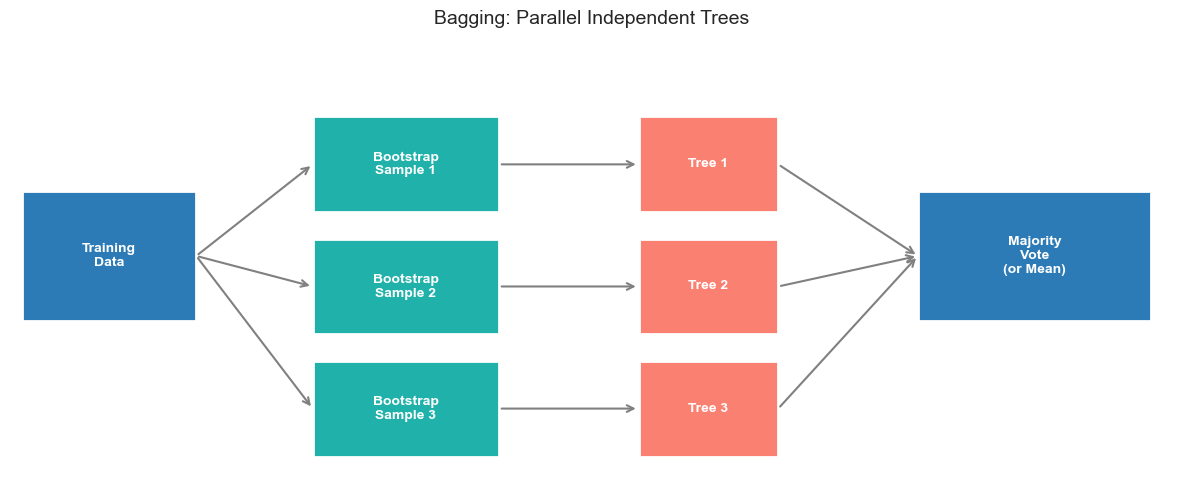

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

# Boxes
def box(ax, x, y, w, h, text, color='steelblue', fontsize=10):
    ax.add_patch(plt.Rectangle((x, y), w, h, color=color, ec='white', lw=2, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, color='white', fontweight='bold', zorder=3)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

box(ax, 0.01, 0.35, 0.15, 0.3, 'Training\nData', color='#2c7bb6')

bootstrap_x = 0.26
for i, label in enumerate(['Bootstrap\nSample 1', 'Bootstrap\nSample 2', 'Bootstrap\nSample 3']):
    y_pos = 0.6 - i * 0.28
    box(ax, bootstrap_x, y_pos, 0.16, 0.22, label, color='lightseagreen')
    arrow(ax, 0.16, 0.5, bootstrap_x, y_pos + 0.11)

tree_x = 0.54
for i, label in enumerate(['Tree 1', 'Tree 2', 'Tree 3']):
    y_pos = 0.6 - i * 0.28
    box(ax, tree_x, y_pos, 0.12, 0.22, label, color='salmon')
    arrow(ax, bootstrap_x + 0.16, y_pos + 0.11, tree_x, y_pos + 0.11)

box(ax, 0.78, 0.35, 0.2, 0.3, 'Majority\nVote\n(or Mean)', color='#2c7bb6')
for i in range(3):
    y_pos = 0.6 - i * 0.28
    arrow(ax, tree_x + 0.12, y_pos + 0.11, 0.78, 0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Bagging: Parallel Independent Trees', fontsize=14, pad=10)
plt.tight_layout()
plt.show()


## How Gradient Boosting Works


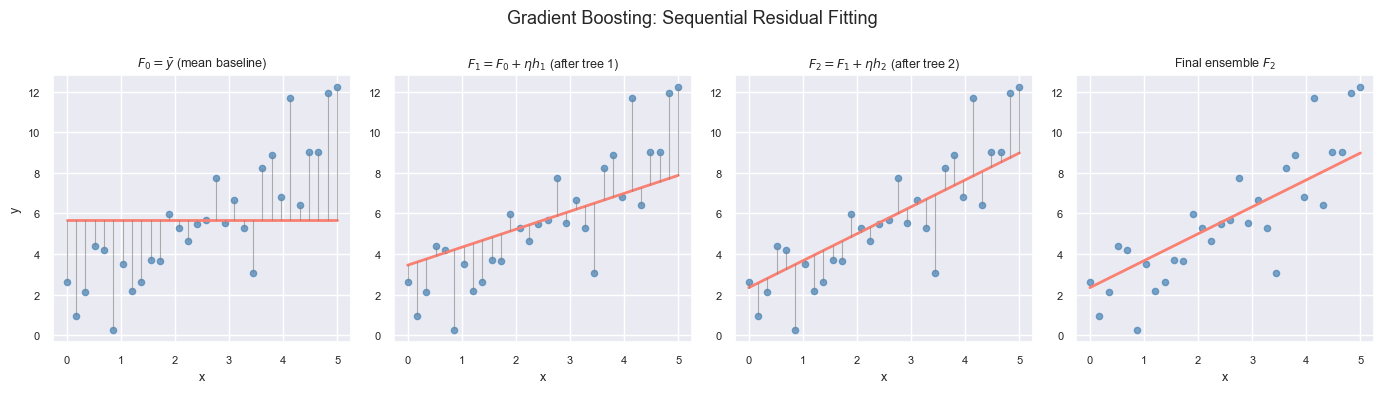

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
np.random.seed(0)
x = np.linspace(0, 5, 30)
y_true = 2 * x + np.random.randn(30) * 1.5

F0 = np.full_like(y_true, y_true.mean())
r1 = y_true - F0

# Fit a simple tree to residuals (simulate with linear fit for diagram)
c1 = np.polyfit(x, r1, 1)
h1 = np.polyval(c1, x)
eta = 0.5
F1 = F0 + eta * h1
r2 = y_true - F1

c2 = np.polyfit(x, r2, 1)
h2 = np.polyval(c2, x)
F2 = F1 + eta * h2

steps = [
    (axes[0], F0, y_true, r1, '$F_0 = \\bar{y}$ (mean baseline)'),
    (axes[1], F1, y_true, r2, '$F_1 = F_0 + \\eta h_1$ (after tree 1)'),
    (axes[2], F2, y_true, y_true - F2, '$F_2 = F_1 + \\eta h_2$ (after tree 2)'),
    (axes[3], F2, y_true, None, 'Final ensemble $F_2$'),
]

for ax, F, y, resid, title in steps:
    ax.scatter(x, y, color='steelblue', s=20, alpha=0.7, label='Data')
    ax.plot(x, F, color='salmon', lw=2, label='Prediction')
    if resid is not None:
        for xi, yi, fi in zip(x, y, F):
            ax.plot([xi, xi], [fi, yi], color='gray', lw=0.8, alpha=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('y', fontsize=9)
plt.suptitle('Gradient Boosting: Sequential Residual Fitting', fontsize=13)
plt.tight_layout()
plt.show()


## Dataset Description

**Classification:** `heart.csv` (1025 samples, 13 features). Predict presence of heart disease.
Key features: age, chest pain type (`cp`), max heart rate (`thalach`), ST depression (`oldpeak`).

**Regression:** `bodyfat.csv` (252 samples, 14 features). Predict body fat percentage.
Key features: Density, Age, Weight, and circumference measurements.


In [4]:
# Classification dataset
try:
    df = pd.read_csv('../../../data/heart.csv')
    X_cls = df.drop(columns=['target']).values.astype(float)
    y_cls = df['target'].values
    print(f'Loaded heart dataset: {X_cls.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_breast_cancer
    data = load_breast_cancer()
    X_cls, y_cls = data.data, data.target
    print('CSV not found. using breast cancer dataset')

scaler_cls = StandardScaler()
X_cls_s = scaler_cls.fit_transform(X_cls)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cls_s, y_cls, test_size=0.2, random_state=42)


Loaded heart dataset: (1025, 13)


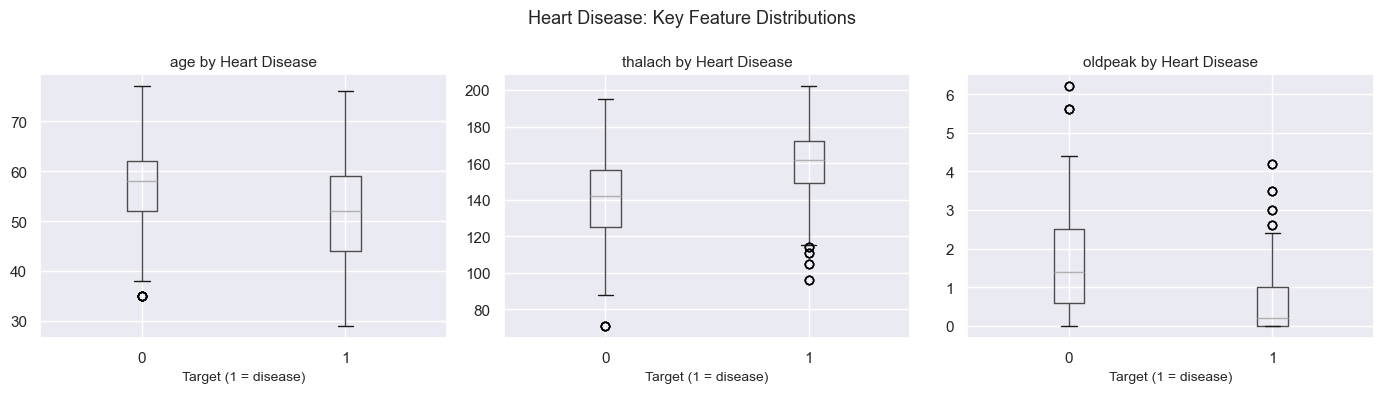

In [5]:
# EDA: heart disease feature distributions
try:
    df_eda = pd.read_csv('../../../data/heart.csv')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, feat in zip(axes, ['age', 'thalach', 'oldpeak']):
        df_eda.boxplot(column=feat, by='target', ax=ax)
        ax.set_title(f'{feat} by Heart Disease', fontsize=11)
        ax.set_xlabel('Target (1 = disease)', fontsize=10)
    plt.suptitle('Heart Disease: Key Feature Distributions', fontsize=13)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('CSV not found. Skipping EDA.')


## Random Forest Classifier


In [6]:
rf = RandomForestClassifier(n_estimators=50, max_depth=5)
rf.fit(X_tr_c, y_tr_c)
print(f'Random Forest Test Accuracy: {accuracy_score(y_te_c, rf.predict(X_te_c)):.4f}')


Random Forest Test Accuracy: 0.8732


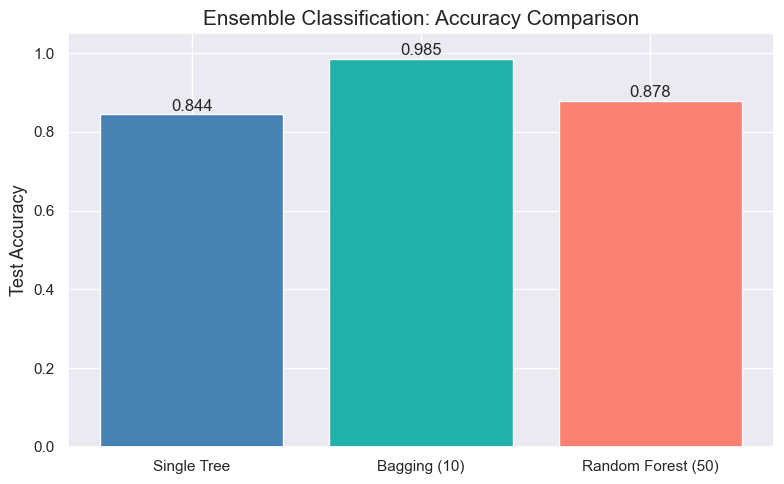

In [7]:
# Compare classification methods
methods_cls = ['Single Tree', 'Bagging (10)', 'Random Forest (50)']
models_cls = [
    DecisionTreeClassifier(max_depth=5),
    BaggingClassifier(n_estimators=10),
    RandomForestClassifier(n_estimators=50, max_depth=5),
]

accs = []
for model in models_cls:
    model.fit(X_tr_c, y_tr_c)
    accs.append(accuracy_score(y_te_c, model.predict(X_te_c)))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods_cls, accs, color=['steelblue', 'lightseagreen', 'salmon'])
plt.ylim(0, 1.05)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=13)
plt.title('Ensemble Classification: Accuracy Comparison', fontsize=15)
plt.tight_layout()
plt.show()


## Gradient Boosting Regressor


In [8]:
# Regression dataset
try:
    df_fat = pd.read_csv('../../../data/bodyfat.csv')
    target_col = 'BodyFat' if 'BodyFat' in df_fat.columns else df_fat.columns[-1]
    X_reg = df_fat.drop(columns=[target_col]).values.astype(float)
    y_reg = df_fat[target_col].values.astype(float)
    print(f'Loaded body fat dataset: {X_reg.shape}')
except FileNotFoundError:
    from sklearn.datasets import make_regression
    X_reg, y_reg = make_regression(n_samples=300, n_features=8, noise=5, random_state=1)
    print('CSV not found. using synthetic regression data')

scaler_reg = StandardScaler()
X_reg_s = scaler_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg_s, y_reg, test_size=0.2, random_state=42)


Loaded body fat dataset: (252, 14)


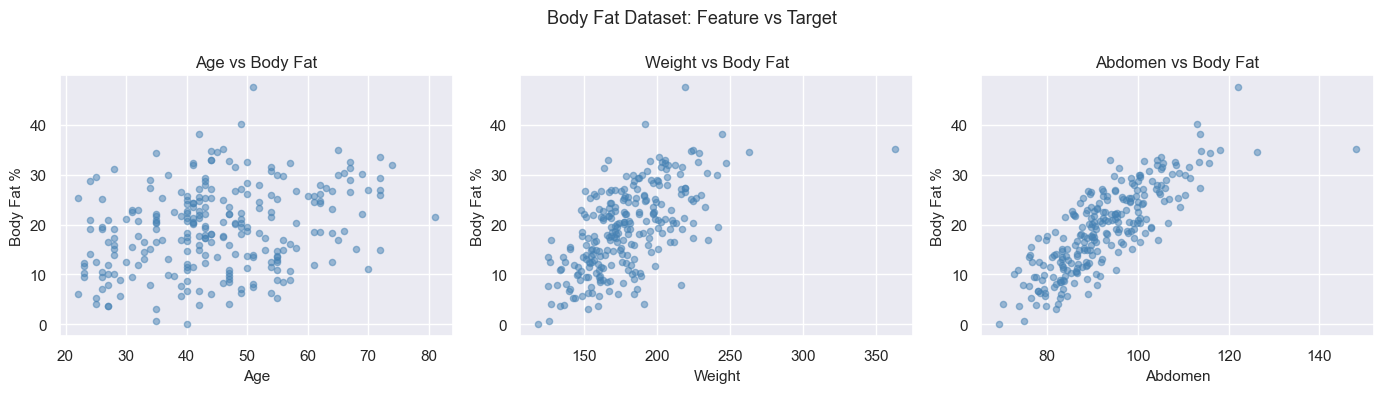

In [9]:
# EDA: body fat feature distributions
try:
    df_fat_eda = pd.read_csv('../../../data/bodyfat.csv')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, feat in zip(axes, ['Age', 'Weight', 'Abdomen']):
        ax.scatter(df_fat_eda[feat], df_fat_eda['BodyFat'], alpha=0.5, color='steelblue', s=20)
        ax.set_xlabel(feat, fontsize=11)
        ax.set_ylabel('Body Fat %', fontsize=11)
        ax.set_title(f'{feat} vs Body Fat', fontsize=12)
    plt.suptitle('Body Fat Dataset: Feature vs Target', fontsize=13)
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('CSV not found. Skipping EDA.')


In [10]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
gbr.fit(X_tr_r, y_tr_r)
print(f'Gradient Boosting R²:       {r2_score(y_te_r, gbr.predict(X_te_r)):.4f}')
print(f'Gradient Boosting MSE:      {mse(y_te_r, gbr.predict(X_te_r)):.4f}')
print(f'Number of trees:            {len(gbr.estimators_)}')


Gradient Boosting R²:       0.9982
Gradient Boosting MSE:      0.0755
Number of trees:            100


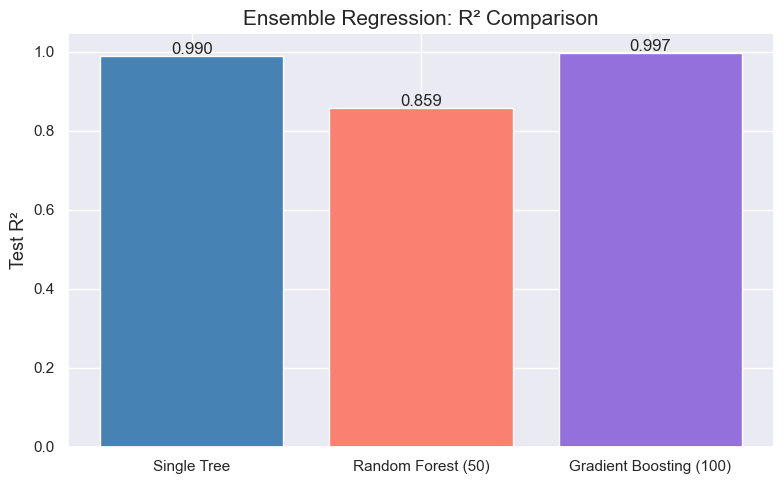

In [11]:
# Compare regression methods
methods_reg = ['Single Tree', 'Random Forest (50)', 'Gradient Boosting (100)']
r2s = []
for model in [
    DecisionTreeRegressor(max_depth=5),
    RandomForestRegressor(n_estimators=50, max_depth=5),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
]:
    model.fit(X_tr_r, y_tr_r)
    r2s.append(r2_score(y_te_r, model.predict(X_te_r)))

plt.figure(figsize=(8, 5))
bars = plt.bar(methods_reg, r2s, color=['steelblue', 'salmon', 'mediumpurple'])
for bar, r2 in zip(bars, r2s):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{r2:.3f}', ha='center', fontsize=12)
plt.ylabel('Test R²', fontsize=13)
plt.title('Ensemble Regression: R² Comparison', fontsize=15)
plt.tight_layout()
plt.show()


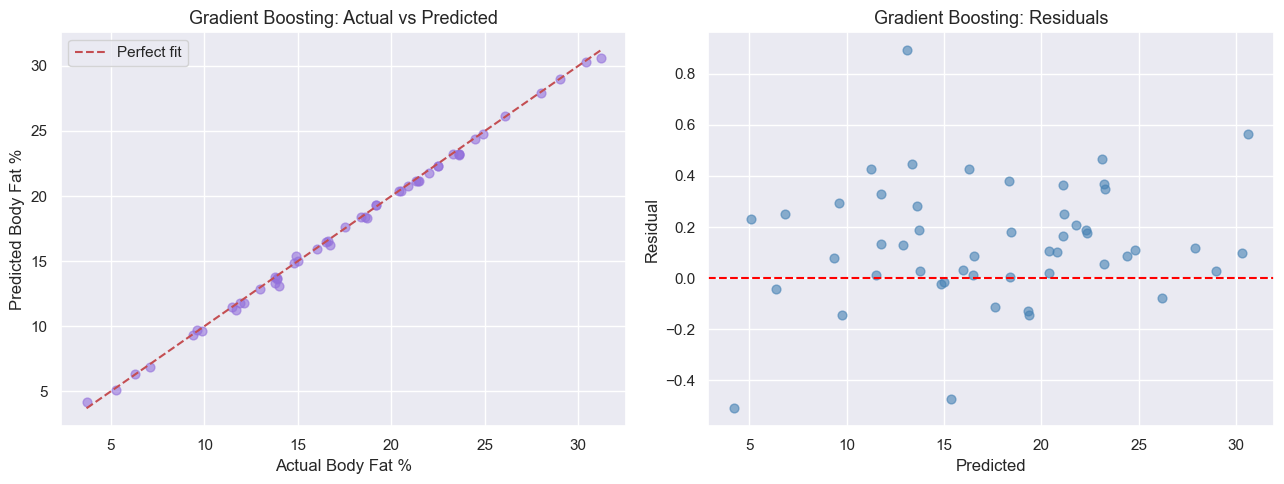

In [12]:
y_pred_gbr = gbr.predict(X_te_r)
residuals = y_te_r - y_pred_gbr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lims = [min(y_te_r.min(), y_pred_gbr.min()), max(y_te_r.max(), y_pred_gbr.max())]
axes[0].scatter(y_te_r, y_pred_gbr, alpha=0.6, color='mediumpurple', s=40)
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Body Fat %', fontsize=12)
axes[0].set_ylabel('Predicted Body Fat %', fontsize=12)
axes[0].set_title('Gradient Boosting: Actual vs Predicted', fontsize=13)
axes[0].legend()

axes[1].scatter(y_pred_gbr, residuals, alpha=0.6, color='steelblue', s=40)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title('Gradient Boosting: Residuals', fontsize=13)

plt.tight_layout()
plt.show()


## Interpretation

- **Bagging** reduces variance by averaging over many uncorrelated trees. Most effective when single trees overfit.
- **Random Forest** improves on bagging by also randomizing feature selection at each split, further decorrelating trees.
- **Gradient Boosting** reduces bias by fitting each tree to the residuals of the current ensemble. Powerful for regression on structured data.
- The comparison bar charts show that ensembles consistently outperform a single tree on both tasks.
- The residuals plot for Gradient Boosting shows errors randomly distributed around 0, indicating a well-calibrated model.
